# PatchTST OHLCV forecasting -- HF PatchTSTModel replication of steven's task

`steven/src/models/patchtst.py` is a hand-rolled PatchTST-style transformer: it patches
the input (7-bar / 1-trading-day patches) and self-attends across patches, but does
**early channel fusion** -- all 7 feature channels are flattened together into one linear
patch embedding before any attention happens. It does not use the paper's channel-independence
design, and has no way to toggle channel-mixing on/off.

This notebook replicates steven's exact **task** (same data, same target parameterization,
same loss) with the real HF `PatchTSTModel` backbone instead, which *does* implement
channel-independent patching (each channel patched/embedded separately) with an optional
`channel_attention` sublayer to let channels cross-inform each other. That gives us a lever
steven's architecture structurally can't offer: toggle `CHANNEL_ATTENTION` below and rerun to
compare channel-independent vs. channel-mixing on the identical task/loss/data.

**Kept identical to steven's setup, for a fair comparison:**
- Data: `steven/data/spy_ohlcv_1h.parquet`, same train/val/test date splits (`steven/src/data_pipeline.py`).
- Target parameterization: anchored log-returns per horizon bar (`open_ret`, `body_ret`,
  `upper_wick`, `lower_wick`) + `log_volume_norm`, 3 bars ahead (`HORIZON=3`), reused directly
  from `steven/src/data_pipeline.py`/`steven/src/losses.py` (`build_dataset`, `unpack_y`,
  `weighted_mse_loss`, `reconstruct_prices`, `reconstruct_volume`) -- no reimplementation.
- Loss: the same deterministic weighted MSE (`w_price=1.0`, `w_vol=0.5`), same bounded output
  (`tanh`/`sigmoid` x `MAX_LOG_RETURN`) applied to the head's raw output before the loss --
  this notebook's model produces the exact same 15-dim output shape/bounding as steven's, so
  `weighted_mse_loss`/`unpack_y` are reused unmodified.
- Patch structure: `patch_length=7`, `patch_stride=7` (non-overlapping, one trading day per
  patch), matching steven's `PATCH_LEN=7`.
- Training hyperparameters: `lr=6e-4`, `weight_decay=1e-4`, `batch_size=512`, 20 epochs x
  20,000 resampled windows/epoch -- from `steven/configs/patchtst.yaml`.

**One deliberate simplification**: steven's model trains on a variable-context curriculum
(2-10 trading days, resampled per window). HF `PatchTSTModel` patchifies a single fixed
`context_length` per model, so this notebook fixes `context_length=MAX_CONTEXT=70` (10 trading
days, steven's longest curriculum option) rather than replicating the curriculum -- most
directly comparable to steven's own "long" context bucket in `steven/outputs/metrics.json`,
not his "overall" (mixed-length) numbers.

**Deferred**: the long-only limit-order backtest (`steven/src/evaluate.py`'s `run_backtest`)
is not implemented here -- per instruction, that comes after we've confirmed which
architecture/`channel_attention` setting is actually better on the forecasting metrics.

## Colab setup

In [1]:
!nvidia-smi --query-gpu=name,memory.total --format=csv

name, memory.total [MiB]
NVIDIA A100-SXM4-80GB, 81920 MiB


In [2]:
import os

REPO_URL = "https://github.com/WoodyChang21/ECE1508_GenAI.git"
BRANCH = "PatchTST_OLCV"

if not os.path.isdir("ECE1508_GenAI"):
    !git clone -b {BRANCH} {REPO_URL}
else:
    !cd ECE1508_GenAI && git pull

%cd ECE1508_GenAI

Cloning into 'ECE1508_GenAI'...
remote: Enumerating objects: 673, done.
remote: Counting objects: 100% (185/185), done.
remote: Compressing objects: 100% (133/133), done.
remote: Total 673 (delta 85), reused 143 (delta 52), pack-reused 488 (from 1)
Receiving objects: 100% (673/673), 21.69 MiB | 18.32 MiB/s, done.
Resolving deltas: 100% (286/286), done.
/content/ECE1508_GenAI


In [3]:
# torch is preinstalled on Colab; transformers is the one addition vs. steven's own
# colab_train.ipynb (steven's hand-rolled model has no library dependency for this).
!pip install -q transformers mplfinance pyyaml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 7.4 MB/s eta 0:00:00


In [4]:
import torch
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

CUDA available: True
GPU: NVIDIA A100-SXM4-80GB


## Imports and config

`sys.path` is set up so `from src.data_pipeline import ...` / `from src.losses import ...`
resolve the same way steven's own scripts import them (both insert `steven/` itself onto
the path, not the repo root -- see `steven/src/train_patchtst.py`).

In [5]:
import sys, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from transformers import PatchTSTConfig, PatchTSTModel

# Normalise cwd to the repo root regardless of whether this notebook is opened from
# within steven/ (local Jupyter) or the repo root (Colab, after the clone cell above).
if os.path.basename(os.getcwd()) == 'steven':
    os.chdir('..')
sys.path.insert(0, 'steven')

from src.data_pipeline import (
    build_dataset, extract_arrays, WindowSampler, build_window,
    reconstruct_prices, reconstruct_volume,
    MAX_CONTEXT, HORIZON, N_FEATURE_CHANNELS, MAX_LOG_RETURN,
)
from src.losses import weighted_mse_loss, unpack_y

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

DATA_PATH = 'steven/data/spy_ohlcv_1h.parquet'

# -- Toggle this and rerun to compare channel-independent vs. channel-mixing on the
# identical task/loss/data -- the whole point of replicating steven's task with HF
# PatchTSTModel instead of his early-channel-fusion architecture.
CHANNEL_ATTENTION = False

# -- Model hyperparameters -- matched to steven/configs/patchtst.yaml's model block
# (d_model, nhead->num_attention_heads, num_layers->num_hidden_layers, dropout) so
# model capacity is comparable, not just the loss function.
D_MODEL      = 64
NUM_HEADS    = 4
NUM_LAYERS   = 3
DROPOUT      = 0.1
HEAD_DROPOUT = 0.0

# -- Patch structure -- matches steven's PATCH_LEN=7 (one trading day, non-overlapping).
PATCH_LEN    = 7
PATCH_STRIDE = 7

# -- Training hyperparameters -- from steven/configs/patchtst.yaml, unchanged.
LR                      = 6e-4
WEIGHT_DECAY            = 1e-4
BATCH_SIZE              = 512
MAX_EPOCHS              = 20
TRAIN_WINDOWS_PER_EPOCH = 20000
WINDOWS_PER_EVAL_SET    = 3000

# -- Loss weights -- from steven/configs/patchtst.yaml's loss block, unchanged.
W_PRICE = 1.0
W_VOL   = 0.5

plt.rcParams['figure.figsize'] = (14, 4)

# -- Seed control --------------------------------------------------------
SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
print(f'SEED = {SEED}, CHANNEL_ATTENTION = {CHANNEL_ATTENTION}')

Device: cuda
SEED = 0, CHANNEL_ATTENTION = False


## Model

`PatchTSTModel` backbone (HF's real channel-independent-or-mixing encoder) + a
deterministic, bounded head that reproduces `steven/src/models/patchtst.py`'s
`forward()` output **exactly** -- same 15-dim layout, same `tanh`/`sigmoid` x
`MAX_LOG_RETURN` bounding -- so `weighted_mse_loss`/`unpack_y` from
`steven/src/losses.py` work unmodified on this model's output too.

`scaling=None`: steven's model has no per-window instance normalization (his
`open_ret`/`body_ret`/wicks are raw log-returns, and `log_volume_norm` is already
globally normalized once via train-split stats in `data_pipeline.py`). HF
`PatchTSTModel`'s default `scaling='std'` would add an extra per-window RevIN-style
normalization steven's model never sees -- disabled here so the comparison is about
the encoder architecture (channel-independent/mixing self-attention vs. steven's
early-fusion self-attention), not confounded by an extra normalization layer only
one side has.

Only channels 0-4 (`open_ret`, `body_ret`, `upper_wick`, `lower_wick`,
`log_volume_norm`) are ever forecast -- channels 5/6 (`time_gap_norm`,
`day_bar_index_norm`) are context-only inputs, matching steven's `PRICE_VOL_IDX`
restriction (his `y` target never includes them either).

In [6]:
class PatchTSTOHLCV(nn.Module):
    def __init__(self, config: PatchTSTConfig):
        super().__init__()
        self.backbone = PatchTSTModel(config)
        self.head = nn.Linear(5 * config.d_model, 15)   # 5 forecastable channels x d_model -> 15 targets
        self.dropout = nn.Dropout(config.head_dropout)

    def forward(self, past_values: torch.Tensor):
        base_out = self.backbone(past_values=past_values)
        pooled = base_out.last_hidden_state.mean(dim=2)      # mean-pool across patches: (bs, 7, d_model)
        pooled = self.dropout(pooled[:, :5, :])                # only the 5 forecastable channels: (bs, 5, d_model)
        raw = self.head(pooled.reshape(pooled.shape[0], -1))   # (bs, 15)

        price_raw = raw[:, :12].reshape(-1, 3, 4)
        # Exact same bounding as steven/src/models/patchtst.py's forward() -- keeps
        # this model's output space identical to steven's target space.
        open_ret   = MAX_LOG_RETURN * torch.tanh(price_raw[..., 0])
        body_ret   = MAX_LOG_RETURN * torch.tanh(price_raw[..., 1])
        upper_wick = MAX_LOG_RETURN * torch.sigmoid(price_raw[..., 2])
        lower_wick = MAX_LOG_RETURN * torch.sigmoid(price_raw[..., 3])
        price = torch.stack([open_ret, body_ret, upper_wick, lower_wick], dim=-1)

        volume = raw[:, 12:15]
        return price, volume


def build_model() -> PatchTSTOHLCV:
    config = PatchTSTConfig(
        num_input_channels=N_FEATURE_CHANNELS,   # 7
        context_length=MAX_CONTEXT,              # 70 (fixed -- see markdown above)
        prediction_length=HORIZON,               # 3
        patch_length=PATCH_LEN,
        patch_stride=PATCH_STRIDE,
        d_model=D_MODEL,
        num_attention_heads=NUM_HEADS,
        num_hidden_layers=NUM_LAYERS,
        dropout=DROPOUT,
        head_dropout=HEAD_DROPOUT,
        channel_attention=CHANNEL_ATTENTION,
        scaling=None,   # see markdown above -- steven's model has no per-window normalization
    )
    return PatchTSTOHLCV(config)

## Data

Reuses `build_dataset`/`extract_arrays`/`WindowSampler`/`build_window` from
`steven/src/data_pipeline.py` unmodified -- same feature engineering, same
chronological train/val/test split boundaries as steven's own training run.

In [7]:
df, bounds, stats = build_dataset(DATA_PATH)
feat, opens, closes = extract_arrays(df)

train_sampler = WindowSampler(*bounds['train'])
val_sampler   = WindowSampler(*bounds['val'])
test_sampler  = WindowSampler(*bounds['test'])

print(f'Train rows: {bounds["train"][1] - bounds["train"][0]:,}')
print(f'Val rows  : {bounds["val"][1] - bounds["val"][0]:,}')
print(f'Test rows : {bounds["test"][1] - bounds["test"][0]:,}')


class FixedContextDataset(Dataset):
    """
    Same window construction as steven's WindowDataset (build_window), but every
    window uses the full MAX_CONTEXT (70 bars) -- see the fixed-context caveat in
    the intro markdown. Since ctx_bars == MAX_CONTEXT exactly, build_window's
    padding is always zero-length, so no padding_mask handling is needed here.
    """
    def __init__(self, feat: np.ndarray, opens: np.ndarray, closes: np.ndarray, start_indices: np.ndarray):
        self.feat, self.opens, self.closes = feat, opens, closes
        self.start_indices = start_indices

    def __len__(self):
        return len(self.start_indices)

    def __getitem__(self, i):
        w = build_window(self.feat, self.opens, self.closes, int(self.start_indices[i]), MAX_CONTEXT)
        context = w['masked_tensor'][:MAX_CONTEXT, :N_FEATURE_CHANNELS]
        return {
            'past_values': torch.from_numpy(context),
            'y': torch.from_numpy(w['y']),
            'close_0': w['close_0'],
        }


def collate(batch: list[dict]) -> dict:
    return {
        'past_values': torch.stack([b['past_values'] for b in batch]),
        'y': torch.stack([b['y'] for b in batch]),
        'close_0': np.array([b['close_0'] for b in batch]),
    }

Train rows: 21,042
Val rows  : 3,495
Test rows : 2,469


## Training

In [8]:
def run_epoch(model, loader, optimizer, device, train: bool, loss_history=None, step_holder=None, log_every=10):
    model.train(mode=train)
    total, price_total, vol_total, n = 0.0, 0.0, 0.0, 0
    for batch in loader:
        past_values = batch['past_values'].to(device)
        y = batch['y'].to(device)

        with torch.set_grad_enabled(train):
            price, volume = model(past_values)
            loss, parts = weighted_mse_loss(price, volume, y, W_PRICE, W_VOL)

        if train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            if step_holder is not None:
                step_holder[0] += 1
                if loss_history is not None and (step_holder[0] == 1 or step_holder[0] % log_every == 0):
                    loss_history.append((step_holder[0], float(loss.item())))

        bs = y.shape[0]
        total += loss.item() * bs
        price_total += parts['price_loss'] * bs
        vol_total += parts['vol_loss'] * bs
        n += bs
    return {'loss': total / n, 'price_loss': price_total / n, 'vol_loss': vol_total / n}

In [ ]:
train_starts_full = train_sampler.valid_starts(MAX_CONTEXT)
val_starts_full    = val_sampler.valid_starts(MAX_CONTEXT)
print(f'Valid train starts (ctx=70): {len(train_starts_full):,}')
print(f'Valid val starts (ctx=70)  : {len(val_starts_full):,}')

val_rng = np.random.default_rng(SEED)
n_val = min(WINDOWS_PER_EVAL_SET, len(val_starts_full))
val_starts = val_rng.choice(val_starts_full, size=n_val, replace=False)
val_ds = FixedContextDataset(feat, opens, closes, val_starts)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate)

model = build_model().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# Saved on every val-loss improvement, matching steven/src/train_patchtst.py's own
# checkpointing behaviour -- the .pt always holds the best-val-loss epoch's weights,
# not necessarily the final epoch's. 'config' is saved alongside the weights so a
# later evaluate/backtest script can rebuild the exact same architecture before
# loading state_dict, same pattern steven's own checkpoints use.
CKPT_PATH = 'steven/outputs/patchtst_false_checkpoint.pt'
os.makedirs('steven/outputs', exist_ok=True)

loss_history = []
step_holder = [0]
best_val_loss = float('inf')

for epoch in range(MAX_EPOCHS):
    train_rng = np.random.default_rng(SEED + epoch)
    n_train = min(TRAIN_WINDOWS_PER_EPOCH, len(train_starts_full))
    train_starts = train_rng.choice(train_starts_full, size=n_train, replace=False)
    train_ds = FixedContextDataset(feat, opens, closes, train_starts)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate)

    train_metrics = run_epoch(model, train_loader, optimizer, DEVICE, train=True,
                               loss_history=loss_history, step_holder=step_holder)
    val_metrics = run_epoch(model, val_loader, optimizer, DEVICE, train=False)

    print(f'epoch {epoch+1:2d}/{MAX_EPOCHS}  '
          f'train_loss={train_metrics["loss"]:.5f} (price={train_metrics["price_loss"]:.5f}, vol={train_metrics["vol_loss"]:.5f})  '
          f'val_loss={val_metrics["loss"]:.5f} (price={val_metrics["price_loss"]:.5f}, vol={val_metrics["vol_loss"]:.5f})')

    if val_metrics['loss'] < best_val_loss:
        best_val_loss = val_metrics['loss']
        torch.save({
            'model_state': model.state_dict(),
            'config': {
                'model': {
                    'd_model': D_MODEL,
                    'num_attention_heads': NUM_HEADS,
                    'num_hidden_layers': NUM_LAYERS,
                    'dropout': DROPOUT,
                    'head_dropout': HEAD_DROPOUT,
                    'channel_attention': CHANNEL_ATTENTION,
                    'patch_length': PATCH_LEN,
                    'patch_stride': PATCH_STRIDE,
                },
                'context_length': MAX_CONTEXT,
                'data_path': DATA_PATH,
                'seed': SEED,
            },
        }, CKPT_PATH)
        print(f'  -> saved best checkpoint (val_loss={best_val_loss:.5f}) to {CKPT_PATH}')

print(f'\ndone. best val_loss={best_val_loss:.5f}, checkpoint={CKPT_PATH}')

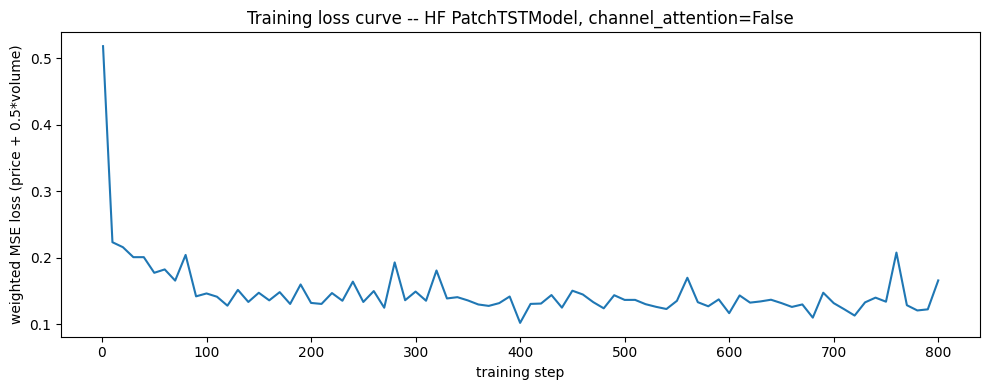

In [10]:
# -- Training loss curve ------------------------------------------
steps, losses = zip(*loss_history)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(steps, losses)
ax.set_xlabel('training step')
ax.set_ylabel('weighted MSE loss (price + 0.5*volume)')
ax.set_title(f'Training loss curve -- HF PatchTSTModel, channel_attention={CHANNEL_ATTENTION}')
plt.tight_layout()
plt.show()

## Evaluation

Same methodology as `steven/src/evaluate.py`'s `metrics_for_slice`: reparam-space
MAE/RMSE (the raw 15-dim vector), reconstructed OHLC MAE/RMSE (via
`reconstruct_prices`), volume MAE/RMSE (via `reconstruct_volume`), and per-horizon-bar
directional accuracy on the close_0-anchored close return
(`open_ret + body_ret`, sign match). Same test seed (`123`) as `evaluate.py`'s default,
so the sampled test windows are reproducible the same way.

**Comparability note**: this model only supports `context_length=70` (steven's "long"
bucket), not his full variable-length curriculum -- so compare against steven's **long**
bucket numbers below, not his "overall" (mixed-length) numbers.

In [11]:
def mae_rmse(pred: np.ndarray, true: np.ndarray) -> tuple[float, float]:
    diff = pred - true
    return float(np.mean(np.abs(diff))), float(np.sqrt(np.mean(diff ** 2)))


test_starts_full = test_sampler.valid_starts(MAX_CONTEXT)
test_rng = np.random.default_rng(123)   # matches steven/src/evaluate.py's --seed default
n_test = min(3000, len(test_starts_full))
test_starts = test_rng.choice(test_starts_full, size=n_test, replace=False)
test_ds = FixedContextDataset(feat, opens, closes, test_starts)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False, collate_fn=collate)

model.eval()
all_true_y, all_pred_y, all_close0 = [], [], []
with torch.no_grad():
    for batch in test_loader:
        pv = batch['past_values'].to(DEVICE)
        price, volume = model(pv)
        pred_y = torch.cat([price.reshape(price.shape[0], -1), volume], dim=1)
        all_true_y.append(batch['y'].numpy())
        all_pred_y.append(pred_y.cpu().numpy())
        all_close0.append(batch['close_0'])

true_y = np.concatenate(all_true_y)
pred_y = np.concatenate(all_pred_y)
close_0 = np.concatenate(all_close0)
n = len(true_y)
print(f'Evaluated on {n:,} fixed-context (70-bar) test windows')

reparam_mae, reparam_rmse = mae_rmse(pred_y, true_y)

true_price = true_y[:, :12].reshape(n, 3, 4)
pred_price = pred_y[:, :12].reshape(n, 3, 4)
true_ohlc = reconstruct_prices(true_price, close_0)
pred_ohlc = reconstruct_prices(pred_price, close_0)
ohlc_mae, ohlc_rmse = mae_rmse(pred_ohlc, true_ohlc)

true_vol_norm = true_y[:, 12:15]
pred_vol_norm = pred_y[:, 12:15]
true_vol = reconstruct_volume(true_vol_norm, stats)
pred_vol = reconstruct_volume(pred_vol_norm, stats)
vol_mae, vol_rmse = mae_rmse(pred_vol, true_vol)

true_close_ret = true_price[:, :, 0] + true_price[:, :, 1]
pred_close_ret = pred_price[:, :, 0] + pred_price[:, :, 1]
dir_acc = (np.sign(pred_close_ret) == np.sign(true_close_ret)).mean(axis=0)

print(f'\n=== HF PatchTSTModel, channel_attention={CHANNEL_ATTENTION}, context=70 (fixed) ===')
print(f'  reparam MAE / RMSE : {reparam_mae:.5f} / {reparam_rmse:.5f}')
print(f'  OHLC MAE / RMSE    : {ohlc_mae:.4f} / {ohlc_rmse:.4f}')
print(f'  volume MAE / RMSE  : {vol_mae:,.1f} / {vol_rmse:,.1f}')
print(f'  dir acc per bar    : {dir_acc[0]:.4f} / {dir_acc[1]:.4f} / {dir_acc[2]:.4f}')

print('\n=== For comparison: steven/outputs/metrics.json, PatchTST, "long" bucket (ctx 56-70 bars) ===')
print('  reparam MAE / RMSE : 0.22700 / 0.64267')
print('  OHLC MAE / RMSE    : 11.2096 / 13.7618')
print('  volume MAE / RMSE  : 5,234,852.5 / 6,398,097.0')
print('  dir acc per bar    : 0.5075 / 0.5285 / 0.5405')

print('\n=== For reference only (different context-length mix, not directly comparable): steven "overall" ===')
print('  reparam MAE / RMSE : 0.21567 / 0.60949')
print('  OHLC MAE / RMSE    : 11.6655 / 14.4080')
print('  volume MAE / RMSE  : 4,865,737.5 / 6,022,999.5')
print('  dir acc per bar    : 0.5270 / 0.5163 / 0.5220')

Evaluated on 2,397 fixed-context (70-bar) test windows

=== HF PatchTSTModel, channel_attention=False, context=70 (fixed) ===
  reparam MAE / RMSE : 0.11409 / 0.43659
  OHLC MAE / RMSE    : 3.7186 / 4.8807
  volume MAE / RMSE  : 2,201,341.8 / 3,897,552.0
  dir acc per bar    : 0.5282 / 0.5411 / 0.5540

=== For comparison: steven/outputs/metrics.json, PatchTST, "long" bucket (ctx 56-70 bars) ===
  reparam MAE / RMSE : 0.22700 / 0.64267
  OHLC MAE / RMSE    : 11.2096 / 13.7618
  volume MAE / RMSE  : 5,234,852.5 / 6,398,097.0
  dir acc per bar    : 0.5075 / 0.5285 / 0.5405

=== For reference only (different context-length mix, not directly comparable): steven "overall" ===
  reparam MAE / RMSE : 0.21567 / 0.60949
  OHLC MAE / RMSE    : 11.6655 / 14.4080
  volume MAE / RMSE  : 4,865,737.5 / 6,022,999.5
  dir acc per bar    : 0.5270 / 0.5163 / 0.5220


## Caveats and recommended next steps

- **One seed, one trained model, one `channel_attention` setting per run.** Change
  `CHANNEL_ATTENTION` in the imports/config cell above and rerun to get the other
  setting's numbers -- that comparison (channel-independent vs. channel-mixing on the
  identical task/loss/data) is the main point of this notebook.
- **Fixed context (70 bars) vs. steven's variable-length curriculum.** Compare against
  steven's "long" bucket, not "overall" -- see the evaluation markdown above. If this
  approach looks promising, replicating the curriculum (via HF's `past_observed_mask`
  for left-padding shorter contexts) would be the natural next step, not yet built here.
- **No backtest yet.** `steven/src/evaluate.py`'s long-only limit-order backtest
  (`run_backtest`) is deferred until we've picked the better architecture/`channel_attention`
  setting on the forecasting metrics above.
- **Same loss, but not a perfectly controlled experiment.** `channel_attention` isn't the
  only architectural difference from steven's model -- his early-channel-fusion patch
  embedding and flatten-all-patches head vs. this notebook's channel-independent patching
  and mean-pooled head are both different regardless of the `channel_attention` setting.
  This notebook isolates the *loss/target/data* variable (now identical), not every
  architectural detail.